## LoRA Inference for Stable Diffusion

This notebook loads a Stable Diffusion base model and your trained LoRA weights from `lora-output-jellyfish` to generate awareness photography images.

Run the cells from top to bottom after your LoRA training has finished.

In [1]:
import torch
from diffusers import AutoencoderKL
from diffusers import StableDiffusionPipeline
from matplotlib import pyplot as plt

# Base Stable Diffusion model and LoRA weights directory
base_model = "runwayml/stable-diffusion-v1-5"
lora_dir = "/home/ament/Fine_tuning_stable_diffusion/lora-output-March-8-26/checkpoint-5000"

# Device and dtype
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print(f"Using device: {device}, dtype: {dtype}")

/home/ament/miniconda3/envs/LOBSTgER/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda, dtype: torch.float16


In [4]:
# Load base Stable Diffusion pipeline

vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").eval().requires_grad_(False).to(device)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model,
    vae=vae.half(),
    torch_dtype=dtype,
)
pipe = pipe.to(device)

# Load your trained LoRA weights

pipe.load_lora_weights(lora_dir)

# Optionally fuse LoRA weights for faster inference (if supported)
try:
    pipe.fuse_lora(lora_scale=1.25)
    print("Fused LoRA weights with scale=1.0")
except AttributeError:
    print("Pipeline does not support fuse_lora; using default LoRA scaling.")

/home/ament/miniconda3/envs/LOBSTgER/lib/python3.10/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 4905.89it/s]4.31it/s]
StableDiffusionSafetyChecker LOAD REPORT from: /home/ament/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 6151.75it/s]0.73it/s]
CLIPTextModel LOAD REPORT from: /home/am

Fused LoRA weights with scale=1.0


100%|██████████| 125/125 [00:15<00:00,  8.08it/s]


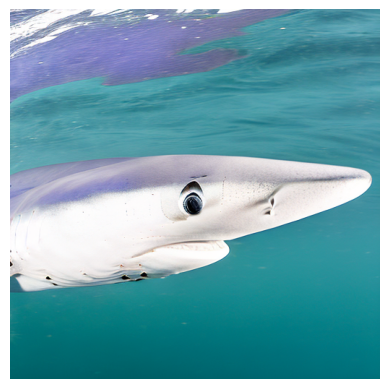

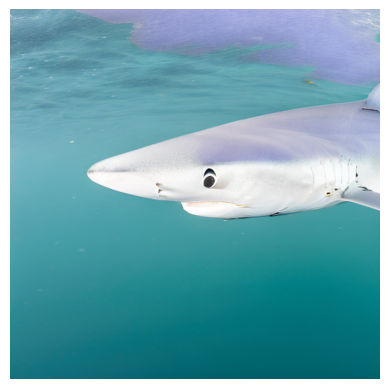

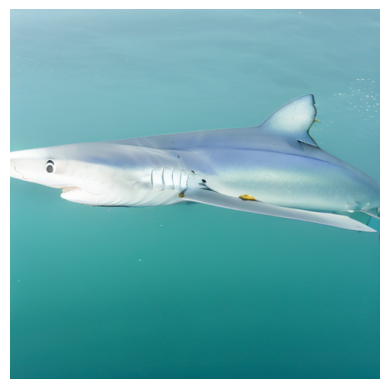

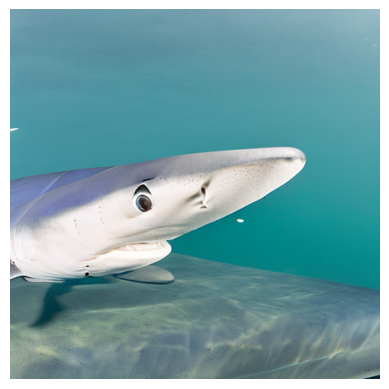

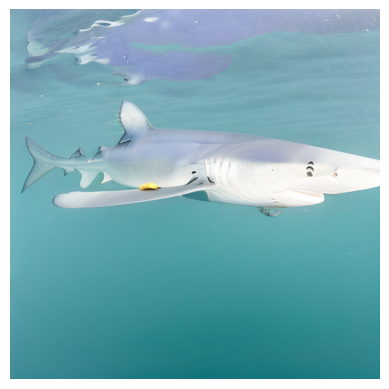

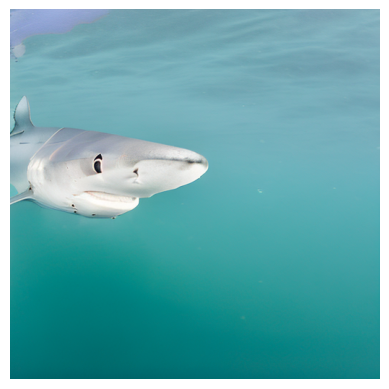

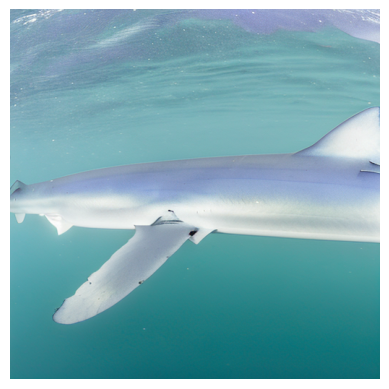

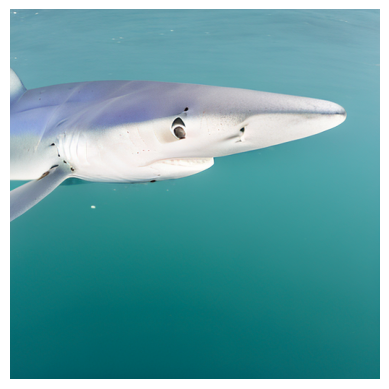

In [19]:
from datetime import datetime

# Prompt tuned to your dataset style
prompt = "A blue shark swimming in light blue water in a shallow reef, raw image in 4K, underwater photography"
negative_prompt = "low quality, blurry, distorted, low resolution, out of focus"

#prompt = "A majestic lion's mane jellyfish, with many entangling tentacles, photo realistic."
#negative_prompt = "The sea surface, the sky, the horizon"

num_images = 8
num_inference_steps = 125
guidance_scale = 8
seed = None

# Set random seed for reproducibility
generator = torch.Generator(device=device)
if seed is not None:
    generator = generator.manual_seed(seed)

pipe.set_progress_bar_config(disable=False)

result = pipe(
    prompt=[prompt] * num_images,
    negative_prompt=[negative_prompt] * num_images if negative_prompt else None,
    num_inference_steps=num_inference_steps,
    guidance_scale=guidance_scale,
    resolution=512,
)

images = result.images

# Display the first image in the notebook
for i in range(num_images):
    plt.imshow(images[i])
    plt.axis('off')
    plt.show()

In [39]:
# Save all generated images to disk
import os

output_dir = "lora_inference_outputs_notebook"
os.makedirs(output_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for i, img in enumerate(images):
    filename = os.path.join(output_dir, f"lora_notebook_space{timestamp}_{i:02d}.png")
    img.save(filename)
    print(f"Saved image {i} to: {filename}")

Saved image 0 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_00.png
Saved image 1 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_01.png
Saved image 2 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_02.png
Saved image 3 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_03.png
Saved image 4 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_04.png
Saved image 5 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_05.png
Saved image 6 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_06.png
Saved image 7 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_07.png
Saved image 8 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_08.png
Saved image 9 to: lora_inference_outputs_notebook/lora_notebook_space20260121_224001_09.png
Saved image 10 to: lora_inference_outputs_notebook/lora_notebook_space20260121_2